In [2]:
import os
import numpy as np
import pandas as pd
from scipy.signal import resample
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

In [3]:
# -----------------------------
# CONFIG
# -----------------------------
RAW_DATA_DIR = "source"
PROCESSED_DIR = "processed"
TIME_STEPS = 200
FEATURE_COLS = ["ax", "ay", "az", "gx", "gy", "gz"]

os.makedirs(PROCESSED_DIR, exist_ok=True)

# -----------------------------
# Helper functions
# -----------------------------
def extract_label(filename):
    # Example: user1_digit5_trial023.csv → 5
    return int(filename.split("digit")[1].split("_")[0])

def load_and_process_csv(filepath):
    df = pd.read_csv(filepath)

    # Select IMU features
    data = df[FEATURE_COLS].values

    # Resample to fixed length
    data_resampled = resample(data, TIME_STEPS)

    return data_resampled

# -----------------------------
# Load all data
# -----------------------------
X = []
y = []

for user in os.listdir(RAW_DATA_DIR):
    user_path = os.path.join(RAW_DATA_DIR, user)

    if not os.path.isdir(user_path):
        continue

    for file in os.listdir(user_path):
        if file.endswith(".csv"):
            file_path = os.path.join(user_path, file)

            sequence = load_and_process_csv(file_path)
            label = extract_label(file)

            X.append(sequence)
            y.append(label)

X = np.array(X)   # (N, 200, 6)
y = np.array(y)   # (N,)

print("Total samples:", X.shape[0])
print("Input shape:", X.shape)

# -----------------------------
# Train / Val / Test split
# -----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# -----------------------------
# Normalization (IMPORTANT)
# -----------------------------
scaler = StandardScaler()

# Fit only on training data
X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
scaler.fit(X_train_reshaped)

def normalize(X, scaler):
    X_reshaped = X.reshape(-1, X.shape[-1])
    X_scaled = scaler.transform(X_reshaped)
    return X_scaled.reshape(X.shape)

X_train = normalize(X_train, scaler)
X_val = normalize(X_val, scaler)
X_test = normalize(X_test, scaler)

# Save scaler for inference
joblib.dump(scaler, os.path.join(PROCESSED_DIR, "scaler.pkl"))

# -----------------------------
# Save processed data
# -----------------------------
np.save(os.path.join(PROCESSED_DIR, "X_train.npy"), X_train)
np.save(os.path.join(PROCESSED_DIR, "X_val.npy"), X_val)
np.save(os.path.join(PROCESSED_DIR, "X_test.npy"), X_test)

np.save(os.path.join(PROCESSED_DIR, "y_train.npy"), y_train)
np.save(os.path.join(PROCESSED_DIR, "y_val.npy"), y_val)
np.save(os.path.join(PROCESSED_DIR, "y_test.npy"), y_test)

print("Processed dataset saved successfully.")


Total samples: 3000
Input shape: (3000, 200, 6)
Processed dataset saved successfully.


In [ ]:
#-----------------------------
# Load and verify saved data
#-----------------------------

X_train = np.load("processed/X_train.npy")
X_val   = np.load("processed/X_val.npy")
X_test  = np.load("processed/X_test.npy")

y_train = np.load("processed/y_train.npy")
y_val   = np.load("processed/y_val.npy")
y_test  = np.load("processed/y_test.npy")

print(X_train.shape, y_train.shape)


(2100, 200, 6) (2100,)


In [ ]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

#-----------------------------
# Build Model
#-----------------------------

def build_model(input_shape, num_classes=10):
    model = Sequential([
        Conv1D(64, kernel_size=3, activation="relu", input_shape=input_shape),
        MaxPooling1D(2),

        Conv1D(128, kernel_size=3, activation="relu"),
        MaxPooling1D(2),

        LSTM(64),

        Dense(64, activation="relu"),
        Dropout(0.5),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [ ]:
from models.cnn_lstm_model import build_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#-----------------------------
# Train Model
#-----------------------------

model = build_model(input_shape=(200, 6))
model.summary()

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("models/airdraw_cnn_lstm.h5", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks
)


done
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 198, 64)           1216      
                                                                 
 max_pooling1d (MaxPooling1D  (None, 99, 64)           0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 97, 128)           24704     
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 48, 128)          0         
 1D)                                                             
                                                                 
 lstm (LSTM)                 (None, 64)                49408     
                                                                 
 dropout (Dropout)           (None, 64)            

15/15 [==============================] - 3s 32ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       1.00      1.00      1.00        45
           2       1.00      1.00      1.00        45
           3       1.00      1.00      1.00        45
           4       1.00      1.00      1.00        45
           5       1.00      1.00      1.00        45
           6       1.00      1.00      1.00        45
           7       1.00      1.00      1.00        45
           8       1.00      1.00      1.00        45
           9       1.00      1.00      1.00        45

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



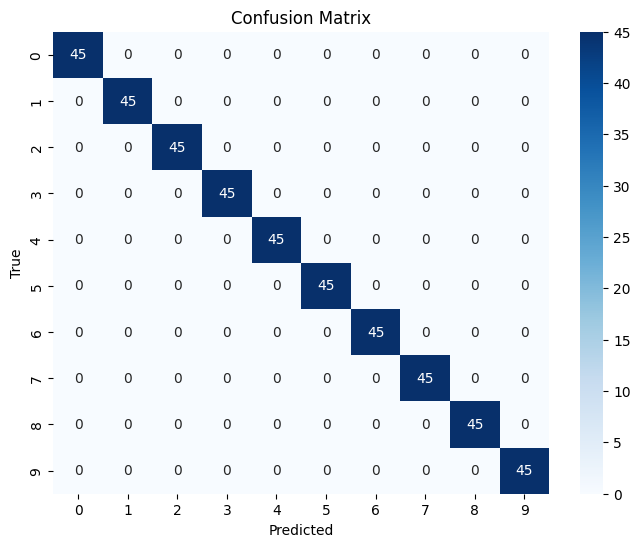

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#-------------------------------
# Evaluate Model
#-------------------------------

y_pred = model.predict(X_test).argmax(axis=1)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import joblib

#-----------------------------
# Predict on new data
#-----------------------------

model = load_model("models/airdraw_cnn_lstm.h5")
scaler = joblib.load("processed/scaler.pkl")

FEATURES = ["ax","ay","az","gx","gy","gz"]

def preprocess_csv(path):
    df = pd.read_csv(path)
    X = df[FEATURES].values[:200]

    X = scaler.transform(X)
    X = X.reshape(1, 200, 6)
    return X

x = preprocess_csv(r"D:\project\FINALPROJECT\source\user3\user3_digit1_trial030.csv")
pred = model.predict(x)

print("Predicted digit:", pred.argmax())


1/1 [==============================] - 1s 1s/step
Predicted digit: 1
